In [1]:
import polars as pl
import os
import numpy as np

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [2]:
DATASET_PATH = '../dataset/E066/'

# Load the data

In [3]:
E066_df = pl.read_parquet(os.path.join(DATASET_PATH, "E066_w_histone_pl.parquet"))

In [4]:
E066_df.head()

gene_id,H3K4me1,H3K4me1_wc,H3K4me1_len,H3K4me3,H3K4me3_wc,H3K4me3_len,H3K9me3,H3K9me3_wc,H3K9me3_len,H3K27me3,H3K27me3_wc,H3K27me3_len,H3K36me3,H3K36me3_wc,H3K36me3_len,E066,label,all_histone
str,list[f64],u32,u32,list[f64],u32,u32,list[f64],u32,u32,list[f64],u32,u32,list[f64],u32,u32,f64,i64,list[list[f64]]
"""ENSG00000000003""","[0.0, 0.0, … 0.0]",9,100,"[0.0, 4.19024, … 0.0]",19,100,"[0.0, 0.0, … 0.0]",0,100,"[0.0, 0.0, … 0.0]",0,100,"[3.39243, 0.0, … 0.0]",1,100,73.205,1,"[[0.0, 0.0, … 0.0], [0.0, 4.19024, … 0.0], … [3.39243, 0.0, … 0.0]]"
"""ENSG00000000005""","[0.0, 0.0, … 0.0]",0,100,"[0.0, 0.0, … 0.0]",0,100,"[0.0, 0.0, … 0.0]",2,100,"[0.0, 0.0, … 0.0]",0,100,"[0.0, 0.0, … 0.0]",0,100,0.191,-1,"[[0.0, 0.0, … 0.0], [0.0, 0.0, … 0.0], … [0.0, 0.0, … 0.0]]"
"""ENSG00000000419""","[0.0, 0.0, … 0.0]",52,100,"[0.0, 0.0, … 0.0]",36,100,"[0.0, 0.0, … 0.0]",2,100,"[0.0, 0.0, … 0.0]",0,100,"[10.55422, 10.55422, … 0.0]",25,100,52.609,1,"[[0.0, 0.0, … 0.0], [0.0, 0.0, … 0.0], … [10.55422, 10.55422, … 0.0]]"
"""ENSG00000000457""","[0.0, 0.0, … 0.0]",35,100,"[0.0, 0.0, … 0.0]",35,100,"[0.0, 0.0, … 0.0]",0,100,"[0.0, 0.0, … 0.0]",0,100,"[0.0, 0.0, … 0.0]",0,100,4.733,1,"[[0.0, 0.0, … 0.0], [0.0, 0.0, … 0.0], … [0.0, 0.0, … 0.0]]"
"""ENSG00000000460""","[0.0, 0.0, … 0.0]",0,100,"[0.0, 0.0, … 0.0]",0,100,"[3.0104, 3.0104, … 0.0]",5,100,"[0.0, 0.0, … 0.0]",0,100,"[0.0, 0.0, … 0.0]",0,100,0.942,-1,"[[0.0, 0.0, … 0.0], [0.0, 0.0, … 0.0], … [0.0, 0.0, … 0.0]]"


In [5]:
# Select X and y column
X = E066_df.select(pl.col('all_histone')).to_series().to_list()
y = E066_df.select(pl.col('label')).to_series().to_list()

In [7]:
print(X[:5])

[[[0.0, 0.0, 5.92171, 5.92171, 5.92171, 5.92171, 5.92171, 5.92171, 5.92171, 5.92171, 5.92171, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [0.0, 4.19024, 4.19024, 4.19024, 4.19024, 4.19024, 11.91877, 11.91877, 11.91877, 11.91877, 11.91877, 11.91877, 11.91877, 11.91877, 11.91877, 11.91877, 11.91877, 11.91877, 11.91877, 11.91877, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,

In [6]:
print(y[:5])

[1, -1, 1, 1, -1]


In [8]:
# Convert to Numpy array
X = np.array(X)
y = np.array(y)

In [9]:
# Split the dataset into training, validation, and test sets
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.66, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

In [10]:
print("Train set shape:", X_train.shape, y_train.shape)
print("Validation set shape:", X_val.shape, y_val.shape)
print("Test set shape:", X_test.shape, y_test.shape)

Train set shape: (6679, 5, 100) (6679,)
Validation set shape: (6483, 5, 100) (6483,)
Test set shape: (6483, 5, 100) (6483,)


In [11]:
# Convert numpy arrays to PyTorch tensors
X_train = torch.from_numpy(X_train).float().unsqueeze(1)
X_val = torch.from_numpy(X_val).float().unsqueeze(1)
X_test = torch.from_numpy(X_test).float().unsqueeze(1)

y_train = torch.from_numpy(y_train).float()
y_val = torch.from_numpy(y_val).float()
y_test = torch.from_numpy(y_test).float()

In [12]:
X_train

tensor([[[[ 3.1394,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
          [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
          [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
          [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
          [ 0.0000,  0.0000,  0.0000,  ...,  2.6767,  2.6767,  2.6767]]],


        [[[ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
          [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
          [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
          [ 0.0000,  0.0000,  0.0000,  ...,  3.5499,  3.5499,  3.5499],
          [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000]]],


        [[[ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
          [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
          [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
          [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.

In [13]:
y_train

tensor([ 1., -1.,  1.,  ...,  1.,  1., -1.])

In [14]:
# Create DataLoaders
batch_size = 32

train_dataset = TensorDataset(X_train, y_train)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

val_dataset = TensorDataset(X_val, y_val)
val_loader = DataLoader(val_dataset, batch_size=batch_size)

test_dataset = TensorDataset(X_test, y_test)
test_loader = DataLoader(test_dataset, batch_size=batch_size)

In [15]:
# Define the model
class DeepClassifier(nn.Module):
    def __init__(self):
        super(DeepClassifier, self).__init__()
        self.conv = nn.Conv2d(1, 50, kernel_size=(5, 10), padding='same')
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool2d(kernel_size=(1, 5))
        self.dropout = nn.Dropout(0.5)
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(25 * 5 * 40, 64) # not sure about this dimension. It should be 625, 125
        self.fc2 = nn.Linear(64, 1) # not sure about this dimension 125, 1
        self.sigmoid = nn.Sigmoid() # need to check with the paper

    def forward(self, x):
        x = self.conv(x)
        x = self.relu(x)
        x = self.pool(x)
        x = self.dropout(x)
        x = self.flatten(x)
        x = self.relu(self.fc1(x))
        x = self.sigmoid(self.fc2(x))
        return x

In [16]:
# Initialize the model, loss function, and optimizer
model = DeepClassifier()
criterion = nn.HingeEmbeddingLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

In [17]:
# Evaluation function
def evaluate(model, data_loader):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in data_loader:
            outputs = model(inputs)
            loss = criterion(outputs.squeeze(), labels)
            total_loss += loss.item() * inputs.size(0)
            predicted = torch.sign(outputs.squeeze())
            correct += (predicted == labels).sum().item()
            total += labels.size(0)
    return total_loss / total, correct / total

In [18]:
# Training loop
num_epochs = 100
train_losses, train_accuracies = [], []
val_losses, val_accuracies = [], []

In [19]:
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for inputs, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs.squeeze(), labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * inputs.size(0)
        predicted = torch.sign(outputs.squeeze())
        correct += (predicted == labels).sum().item()
        total += labels.size(0)
    
    epoch_train_loss = running_loss / total
    epoch_train_acc = correct / total
    
    # Evaluate on validation set
    val_loss, val_accuracy = evaluate(model, val_loader)
    
    train_losses.append(epoch_train_loss)
    train_accuracies.append(epoch_train_acc)
    val_losses.append(val_loss)
    val_accuracies.append(val_accuracy)

    print(f"Epoch [{epoch+1}/{num_epochs}], Train Loss: {epoch_train_loss:.4f}, Train Acc: {epoch_train_acc:.4f}, Val Loss: {val_loss:.4f}, Val Acc: {val_accuracy:.4f}")

/home/amunif/.local/lib/python3.12/site-packages/torch/nn/modules/conv.py:456: UserWarning: Using padding='same' with even kernel lengths and odd dilation may require a zero-padded copy of the input be created (Triggered internally at ../aten/src/ATen/native/Convolution.cpp:1031.)
  return F.conv2d(input, weight, bias, self.stride,


Epoch [1/100], Train Loss: 0.2508, Train Acc: 0.5004, Val Loss: 0.2196, Val Acc: 0.4988
Epoch [2/100], Train Loss: 0.2110, Train Acc: 0.5002, Val Loss: 0.2172, Val Acc: 0.4984
Epoch [3/100], Train Loss: 0.2044, Train Acc: 0.5002, Val Loss: 0.2155, Val Acc: 0.4988
Epoch [4/100], Train Loss: 0.2020, Train Acc: 0.5001, Val Loss: 0.2175, Val Acc: 0.4984
Epoch [5/100], Train Loss: 0.2009, Train Acc: 0.5001, Val Loss: 0.2117, Val Acc: 0.4988
Epoch [6/100], Train Loss: 0.1963, Train Acc: 0.4999, Val Loss: 0.2081, Val Acc: 0.4988
Epoch [7/100], Train Loss: 0.1982, Train Acc: 0.5001, Val Loss: 0.2086, Val Acc: 0.4985
Epoch [8/100], Train Loss: 0.1937, Train Acc: 0.4998, Val Loss: 0.2068, Val Acc: 0.4988
Epoch [9/100], Train Loss: 0.1910, Train Acc: 0.5004, Val Loss: 0.2061, Val Acc: 0.4988
Epoch [10/100], Train Loss: 0.1898, Train Acc: 0.4999, Val Loss: 0.2069, Val Acc: 0.4978
Epoch [11/100], Train Loss: 0.1935, Train Acc: 0.4998, Val Loss: 0.2045, Val Acc: 0.4988
Epoch [12/100], Train Loss: 0.

In [20]:
# Evaluate on test set
test_loss, test_accuracy = evaluate(model, test_loader)
print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}")

Test Loss: 0.1940, Test Accuracy: 0.4867


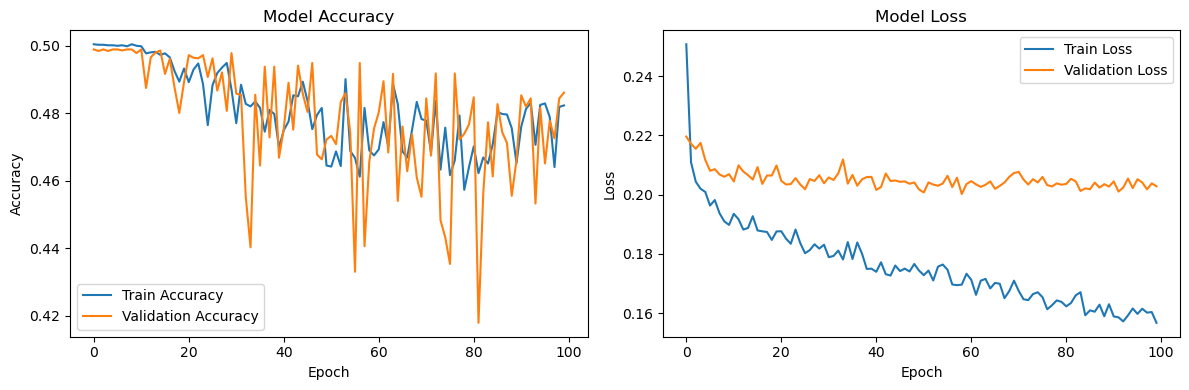

In [21]:
# Visualize training process
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(train_accuracies, label='Train Accuracy')
plt.plot(val_accuracies, label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()